Task 1 : Data Loading & Exploration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.shape

(1470, 35)

In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1470
Number of columns: 35


In [6]:
target = 'Attrition'
features = [col for col in df.columns if col != target]
print("Target column:", target)
print("\nFeature columns:")
for f in features:
    print("  →", f)

Target column: Attrition

Feature columns:
  → Age
  → BusinessTravel
  → DailyRate
  → Department
  → DistanceFromHome
  → Education
  → EducationField
  → EmployeeCount
  → EmployeeNumber
  → EnvironmentSatisfaction
  → Gender
  → HourlyRate
  → JobInvolvement
  → JobLevel
  → JobRole
  → JobSatisfaction
  → MaritalStatus
  → MonthlyIncome
  → MonthlyRate
  → NumCompaniesWorked
  → Over18
  → OverTime
  → PercentSalaryHike
  → PerformanceRating
  → RelationshipSatisfaction
  → StandardHours
  → StockOptionLevel
  → TotalWorkingYears
  → TrainingTimesLastYear
  → WorkLifeBalance
  → YearsAtCompany
  → YearsInCurrentRole
  → YearsSinceLastPromotion
  → YearsWithCurrManager


In [7]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [8]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [9]:
df.select_dtypes(include='number').shape[1]

26

In [10]:
df.select_dtypes(include='object').shape[1]

9

Observation: The dataset is imbalanced as here only 16.12% of employees left the company (237 out of 1470), while 83.88% stayed. This means a model that just predicts no for everyone would already be 84% accurate, which tells us accuracy alone will be a misleading metric for this problem , we will need to rely on precision/ recall/ F1 instead.

Task 2 : Data Cleaning & Preprocessing


In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df['Over18'].unique()

array(['Y'], dtype=object)

In [13]:
df['StandardHours'].unique()

array([80])

In [14]:
df['EmployeeCount'].unique()

array([1])

In [15]:
df = df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount'])

In [16]:
df.shape

(1470, 31)

In [17]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [18]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [19]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [20]:
df_eda = df.copy()

In [21]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime'], drop_first=True)


In [22]:
df.shape

(1470, 45)

In [23]:
df.dtypes.tail(10)

,0
JobRole_Laboratory Technician,bool
JobRole_Manager,bool
JobRole_Manufacturing Director,bool
JobRole_Research Director,bool
JobRole_Research Scientist,bool
JobRole_Sales Executive,bool
JobRole_Sales Representative,bool
MaritalStatus_Married,bool
MaritalStatus_Single,bool
OverTime_Yes,bool


In [24]:
numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
                'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
                'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [26]:
df[numeric_cols].describe().loc[['mean','std']]

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
mean,-3.504377e-17,5.075305e-17,4.350262e-17,7.008755e-17,1.305078e-16,1.691768e-16,6.525392e-17,-2.658493e-17,-9.183886e-17,-4.471102e-17,...,-6.114534e-16,9.667248e-17,6.767074e-17,-1.208406e-18,8.700523e-17,-6.042030e-18,-3.021015e-17,9.063045e-17,1.208406e-18,-2.779334e-17
std,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,...,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00,1.000340e+00


In [27]:
df.dtypes.value_counts()

,count
float64,23
bool,21
int64,1


Task 3 : Exploratory Data Analysis [EDA]

In [28]:
df_eda.shape

(1470, 31)

In [29]:
df_eda['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [30]:
df_eda['Attrition'].unique()

array([1, 0])

In [31]:
df_eda.groupby('Department')['Attrition'].mean() * 100

,Attrition
Department,
Human Resources,19.047619
Research & Development,13.839750
Sales,20.627803


In [32]:
df_eda['Department'].value_counts()

,count
Department,
Research & Development,961
Sales,446
Human Resources,63


In [33]:
df_eda.groupby('JobRole')['Attrition'].mean() * 100

,Attrition
JobRole,
Healthcare Representative,6.870229
Human Resources,23.076923
Laboratory Technician,23.938224
Manager,4.901961
Manufacturing Director,6.896552
Research Director,2.500000
Research Scientist,16.095890
Sales Executive,17.484663
Sales Representative,39.759036


In [34]:
df_eda['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


In [35]:
df_eda.groupby('Attrition')['MonthlyIncome'].mean()

,MonthlyIncome
Attrition,
0,6832.739659
1,4787.092827


In [36]:
df_eda.groupby('Attrition')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [37]:
df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100

,Attrition
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


In [38]:
df_eda['WorkLifeBalance'].value_counts().sort_index()

,count
WorkLifeBalance,
1,80
2,344
3,893
4,153


In [39]:
df_eda['TenureGroup'] = pd.cut(df_eda['YearsAtCompany'], bins=[0, 2, 5, 10, 40], labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])
df_eda.groupby('TenureGroup')['Attrition'].mean() * 100

/tmp/ipykernel_6908/1069842725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby('TenureGroup')['Attrition'].mean() * 100


,Attrition
TenureGroup,
0-2 yrs,28.859060
3-5 yrs,13.824885
6-10 yrs,12.276786
10+ yrs,8.130081


In [40]:
df_eda['TenureGroup'].value_counts().sort_index()

,count
TenureGroup,
0-2 yrs,298
3-5 yrs,434
6-10 yrs,448
10+ yrs,246


1. Department: Although Sales has the highest attrition rate of 20.63%, R&D loses the most employees in absolute terms i.e. almost 133 people due to its much larger headcount , meaning retention efforts focused only on the highest rate department might miss where the company actually loses the most talent.

2. Job Role: Research & Development loses the most people overall, and that's substantially driven by Lab Technicians with 23.94% rate, and almost 62 leavers meanwhile, Sales Representative with 39.76% is the single riskiest role per person, even if its absolute headcount loss is smaller.

3. Monthly Income: Employees who left had a median monthly income of ₹3202, compared to ₹5204 for those who stayed leavers typically earned only 62% of what stayers earned. However, this is a correlation, not proof of causation, since lower pay overlaps heavily with high attrition roles like Sales Representative.

4. Work-Life Balance: Rating 1 is a small i.e. 80 people, high risk with 31.25% group an easy, targeted fix for HR.

5. Tenure: Attrition falls steadily with tenure  from 28.86% in the first 0-2 years down to just 8.13% for employees with 10+ years, roughly a 3.5x difference. With 298 employees currently in that 0-2 year window, this is the highest risk period.


Task 4 : Model Building & Comparison


In [41]:
X = df.drop(columns=['Attrition'])
Y = df['Attrition']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42,stratify=Y)

In [43]:
X_train.shape, X_test.shape

((1176, 44), (294, 44))

In [44]:
Y_train.value_counts(normalize=True) * 100


,proportion
Attrition,
0,83.843537
1,16.156463


In [45]:
Y_test.value_counts(normalize=True) * 100

,proportion
Attrition,
0,84.013605
1,15.986395


In [49]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=Y_train)

In [50]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, Y_train, sample_weight=sample_weights)

GradientBoostingClassifier(random_state=42)

In [51]:
sample_weights[:10]
pd.Series(sample_weights).describe()

,0
count,1176.000000
mean,1.000000
std,0.919925
min,0.596349
25%,0.596349
50%,0.596349
75%,0.596349
max,3.094737


In [52]:
from sklearn.linear_model import LogisticRegression

In [54]:
log_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Task 5 : Model Evaluation

In [57]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

In [58]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [61]:
y_pred_log[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [62]:
y_prob_log[:10]

array([0.32171993, 0.02189145, 0.4454426 , 0.03537396, 0.66509222,
       0.62461043, 0.0803363 , 0.13280096, 0.02121789, 0.2640959 ])

In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

results = {
    'Logistic Regression': {
        'Precision': precision_score(Y_test, y_pred_log),
        'Recall': recall_score(Y_test, y_pred_log),
        'F1-Score': f1_score(Y_test, y_pred_log),
        'ROC-AUC': roc_auc_score(Y_test, y_prob_log),
        'Confusion matrix' : confusion_matrix(Y_test, y_pred_log)
    },
    'Random Forest': {
        'Precision': precision_score(Y_test, y_pred_rf),
        'Recall': recall_score(Y_test, y_pred_rf),
        'F1-Score': f1_score(Y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(Y_test, y_prob_rf),
        'Confusion matrix' : confusion_matrix(Y_test, y_pred_log)
    },
    'Gradient Boosting': {
        'Precision': precision_score(Y_test, y_pred_gb),
        'Recall': recall_score(Y_test, y_pred_gb),
        'F1-Score': f1_score(Y_test, y_pred_gb),
        'ROC-AUC': roc_auc_score(Y_test, y_prob_gb),
        'Confusion matrix' : confusion_matrix(Y_test, y_pred_log)
    }
}

comparison_df = pd.DataFrame(results).T
comparison_df

,Precision,Recall,F1-Score,ROC-AUC,Confusion matrix
Logistic Regression,0.356322,0.659574,0.462687,0.803601,"[[191, 56], [16, 31]]"
Random Forest,0.375,0.06383,0.109091,0.751917,"[[191, 56], [16, 31]]"
Gradient Boosting,0.407407,0.468085,0.435644,0.779051,"[[191, 56], [16, 31]]"


Best performed model: Logistic Regression was the best model because it achieved the highest Recall (66.0%) and ROC-AUC (0.804) among the three models, meaning it catches the most actual leavers and ranks risk most reliably. Random Forest, despite balanced class weights, had a Recall of only 6.4% , missing the vast majority of at risk employees  making it unsuitable despite reasonable precision. Logistic Regression's coefficients are also the easiest to interpret for non tech stakeholders.

In [64]:
from sklearn.metrics import confusion_matrix
cm_log = confusion_matrix(Y_test, y_pred_log)
cm_log

array([[191,  56],
       [ 16,  31]])

In [67]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

In [70]:
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)
feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
43,OverTime_Yes,1.626169,1.626169
23,BusinessTravel_Travel_Frequently,1.596964,1.596964
34,JobRole_Laboratory Technician,1.571637,1.571637
40,JobRole_Sales Representative,1.264294,1.264294
37,JobRole_Research Director,-1.112054,1.112054
30,EducationField_Other,-1.020279,1.020279
24,BusinessTravel_Travel_Rarely,0.903722,0.903722
42,MaritalStatus_Single,0.864502,0.864502
33,JobRole_Human Resources,0.670991,0.670991
16,TotalWorkingYears,-0.612480,0.612480


Task 6 : Visualization

Chart 1 => Bar chart: Attrition rate by Department and Job Role

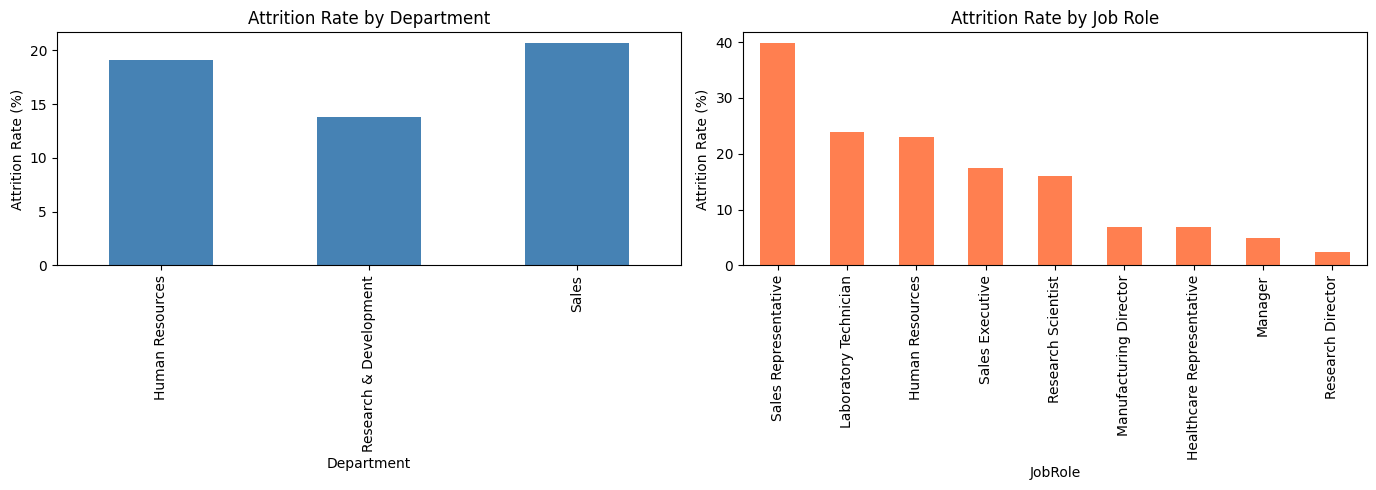

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attrition = df_eda.groupby('Department')['Attrition'].mean() * 100
dept_attrition.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')

role_attrition = df_eda.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100
role_attrition.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('chart1_dept_role_attrition.png', dpi=150)
plt.show()

Chart 2 => Box plot: Monthly Income, left vs stayed

/tmp/ipykernel_6908/661107709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome', palette=['steelblue', 'coral'])


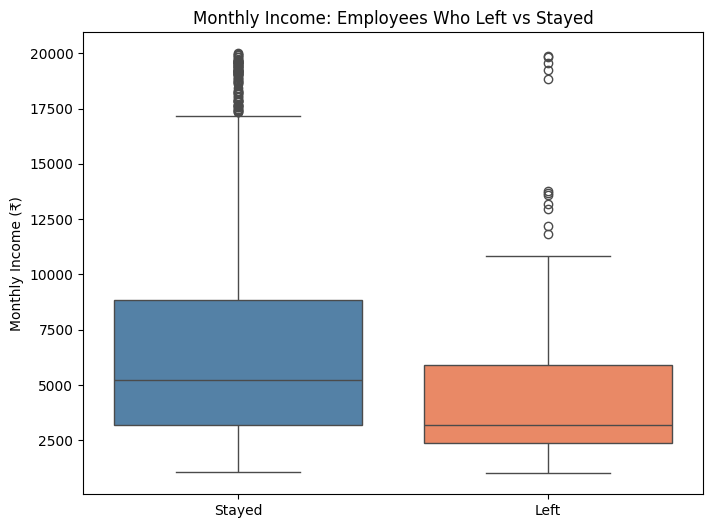

In [72]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_eda, x='Attrition', y='MonthlyIncome', palette=['steelblue', 'coral'])
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.title('Monthly Income: Employees Who Left vs Stayed')
plt.ylabel('Monthly Income (₹)')
plt.xlabel('')
plt.savefig('chart2_income_boxplot.png', dpi=150)
plt.show()

Chart 3 => Confusion Matrix heatmap (best model:Logistic Regression)

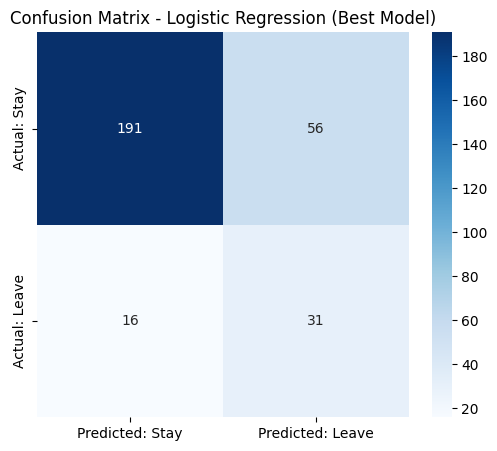

In [73]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted: Stay', 'Predicted: Leave'],yticklabels=['Actual: Stay', 'Actual: Leave'])
plt.title('Confusion Matrix - Logistic Regression (Best Model)')
plt.savefig('chart3_confusion_matrix.png', dpi=150)
plt.show()

Chart 4 => Horizontal bar chart: Top 10 Feature Importances

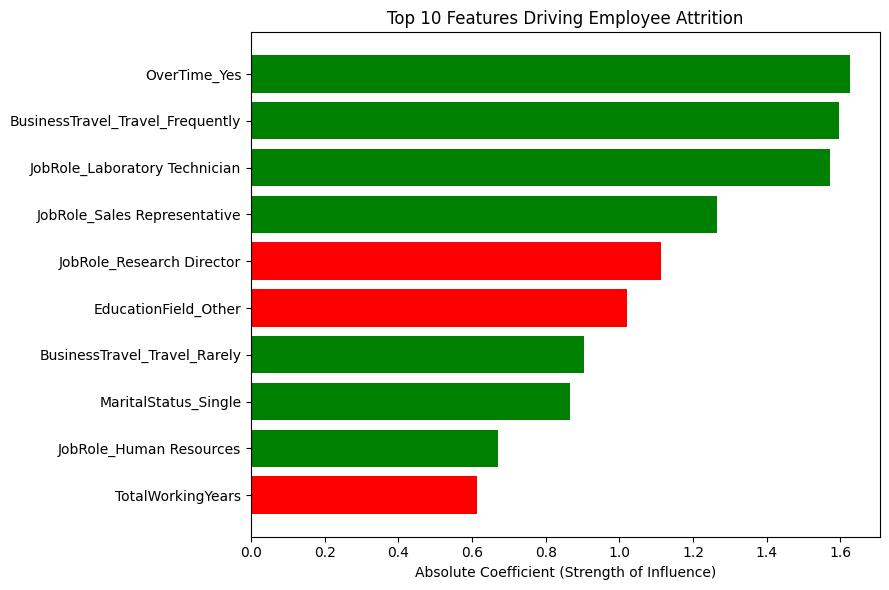

In [74]:
plt.figure(figsize=(9, 6))
top10 = feature_importance.head(10).sort_values('Abs_Coefficient')

colors = ['red' if c < 0 else 'green' for c in top10['Coefficient']]
plt.barh(top10['Feature'], top10['Abs_Coefficient'], color=colors)
plt.xlabel('Absolute Coefficient (Strength of Influence)')
plt.title('Top 10 Features Driving Employee Attrition')
plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150)
plt.show()

Chart 5 => ROC Curve, all 3 models on one graph

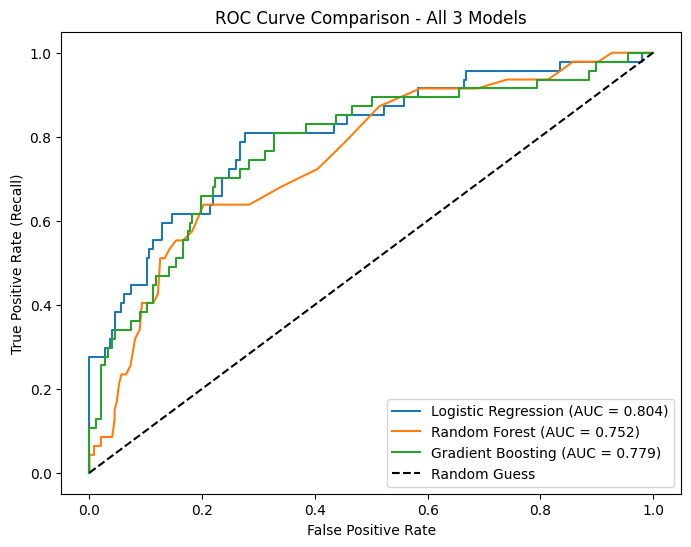

In [76]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_log), ('Random Forest', y_prob_rf), ('Gradient Boosting', y_prob_gb)]:
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    auc = roc_auc_score(Y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison - All 3 Models')
plt.legend()
plt.savefig('chart5_roc_curve.png', dpi=150)
plt.show()

Task 7 : HR Insights & Business Recommendations


**1. Which 3 factors most strongly predict that an employee will leave?**

Working overtime is the single strongest predictor in our model stronger than salary or even job role. Frequent business travel and working as a Sales Representative or Laboratory Technician are the next strongest factors, each significantly raising the likelihood of leaving.

**2. Which department or job role should HR prioritize for retention efforts?**

Sales has the highest attrition rate (20.6%), making it the riskiest department per person. However, R&D loses the most employees overall (~133 people) simply because it's the company's largest department  with Laboratory Technicians driving much of that loss. HR should treat these as two separate priorities, not one.

**3. Does salary alone explain attrition, or are there other stronger factors?**

No , salary alone doesn't explain it. Employees who left earned roughly 62% of what employees who stayed earned, but this gap overlaps heavily with high risk roles like Sales Representative. Overtime and job role appear to be stronger underlying drivers than pay by itself.

**4. Two concrete HR recommendations:**

(1) Flag any employee with sustained overtime for a workload review or manager check in before burnout pushes them to leave.

(2) Specifically target the ~80 employees who report poor work life balance (31% attrition rate, double the company average) for proactive retention conversations.

**5. What limitation should HR be aware of?**

This model reflects historical patterns and will need to be retrained as policies or the workforce change over time. It also only catches about 66% of actual leavers, so it should be used as a tool to prioritize conversations instead of a guaranteed list of who will leave.
